<a href="https://colab.research.google.com/github/mariabenx138-cloud/AtividadeMachineLearningMLAM/blob/main/CP5_2_MachineLearningMLAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
#Imports Básicos

import requests
import json
import urllib.parse
import urllib.request
import csv


# Manipulação de dados e gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Separação treino/teste e padronização
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de CLASSIFICAÇÃO
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Algoritmos de REGRESSÃO
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de classificação
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
# Métricas de regressão
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SEMENTE = 42   # semente fixa: garante resultados reprodutíveis
sns.set_theme(style="whitegrid")

# *Organização da Base de Dados

# * Carregando dados do CSV

In [ ]:
df_sp = pd.read_csv('/content/dados_pib_abcr_sp.csv')
df_rj = pd.read_csv('/content/dados_pib_abcr_rj.csv')

In [ ]:
df_sp.head()

,Ano,PIB_indice,ABCR_indice
0,2006,100,105.99
1,2007,106,110.42
2,2008,111,116.75
3,2009,110,117.55
4,2010,118,121.63


In [ ]:
df_rj.head()

,Ano,PIB_indice,ABCR_indice
0,2006,100,109.40
1,2007,104,107.72
2,2008,108,112.00
3,2009,107,106.68
4,2010,112,113.57


# Análise da relação

In [ ]:
print("========================================")
print("ANÁLISE PARA O ESTADO DE: SÃO PAULO")
print("========================================")

# Calcular a correlação de São Paulo
corr_sp = df_sp['PIB_indice'].corr(df_sp['ABCR_indice'])
print("Correlação em SP:", corr_sp)

ANÁLISE PARA O ESTADO DE: SÃO PAULO
Correlação em SP: 0.984670697619614


In [ ]:
print("========================================")
print("ANÁLISE PARA O ESTADO DE: RIO DE JANEIRO")
print("========================================")

# Passo A: Calcular a correlação do Rio de Janeiro
corr_rj = df_rj['PIB_indice'].corr(df_rj['ABCR_indice'])
print("Correlação de Pearson no RJ:", corr_rj)



ANÁLISE PARA O ESTADO DE: RIO DE JANEIRO
Correlação de Pearson no RJ: 0.8033451339240928


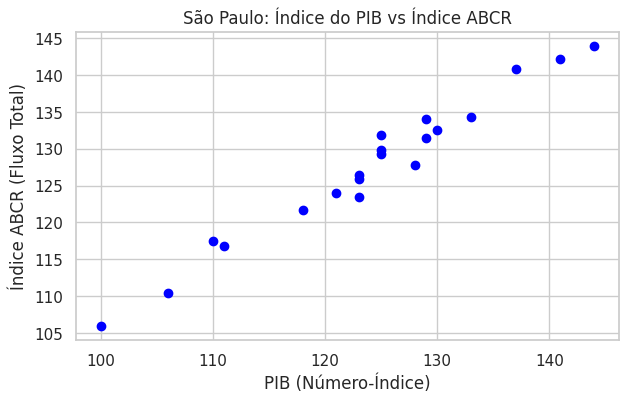

In [ ]:
# Gráfico de dispersão para Sp

plt.figure(figsize=(7, 4))
plt.scatter(df_sp['PIB_indice'], df_sp['ABCR_indice'], color='blue', label='Dados Reais')
plt.title('São Paulo: Índice do PIB vs Índice ABCR')
plt.xlabel('PIB (Número-Índice)')
plt.ylabel('Índice ABCR (Fluxo Total)')
plt.grid(True)
plt.show()


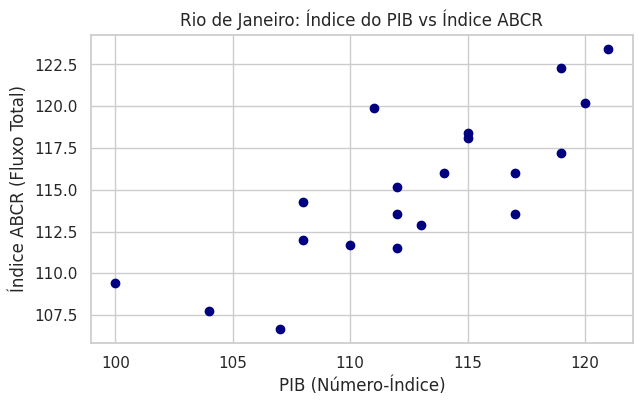

In [ ]:
# Gráfico de dispersão para Rj
plt.figure(figsize=(7, 4))
plt.scatter(df_rj['PIB_indice'], df_rj['ABCR_indice'], color='navy', label='Dados Reais')
plt.title('Rio de Janeiro: Índice do PIB vs Índice ABCR')
plt.xlabel('PIB (Número-Índice)')
plt.ylabel('Índice ABCR (Fluxo Total)')
plt.grid(True)
plt.show()

# Treinamento do modelo

In [ ]:
# Separar os dados de SP (16 anos para Treino, 4 para Teste)
treino_sp = df_sp.iloc[:16]
teste_sp = df_sp.iloc[16:]

X_train_sp = treino_sp[['PIB_indice']]
y_train_sp = treino_sp['ABCR_indice']

X_test_sp = teste_sp[['PIB_indice']]
y_test_sp = teste_sp['ABCR_indice']

In [ ]:
# Separar os dados do RJ (16 anos para Treino, 4 para Teste)
treino_rj = df_rj.iloc[:16]
teste_rj = df_rj.iloc[16:]

X_train_rj = treino_rj[['PIB_indice']]
y_train_rj = treino_rj['ABCR_indice']

X_test_rj = teste_rj[['PIB_indice']]
y_test_rj = teste_rj['ABCR_indice']


In [ ]:
# Treinar o modelo de SP
modelo_sp = LinearRegression()
modelo_sp.fit(X_train_sp, y_train_sp)


LinearRegression()

In [ ]:
#Treinar o modelo do RJ
modelo_rj = LinearRegression()
modelo_rj.fit(X_train_rj, y_train_rj)


LinearRegression()

In [ ]:
# Fazer as previsões para SP
y_pred_sp = modelo_sp.predict(X_test_sp)

In [ ]:

# Fazer as previsões para RJ
y_pred_rj = modelo_rj.predict(X_test_rj)

#Avaliação dos resultados

In [ ]:
# Métricas SP
mae_sp = mean_absolute_error(y_test_sp, y_pred_sp)
mse_sp = mean_squared_error(y_test_sp, y_pred_sp)
r2_sp = r2_score(y_test_sp, y_pred_sp)

In [ ]:
df_tabela_sp = pd.DataFrame({
    'Ano': teste_sp['Ano'],
    'ABCR_Real (Observado)': y_test_sp.values,
    'ABCR_Previsto': np.round(y_pred_sp, 2),
    'Erro (Diferença)': np.round(y_test_sp.values - y_pred_sp, 2)
})

print("=== RESULTADOS NO CONJUNTO DE TESTE: SÃO PAULO ===")
print(df_tabela_sp.to_string(index=False))
print("-" * 50)
print(f"MAE : {mae_sp:.4f}")
print(f"MSE : {mse_sp:.4f}")
print(f"R² : {r2_sp:.4f}")

=== RESULTADOS NO CONJUNTO DE TESTE: SÃO PAULO ===
 Ano  ABCR_Real (Observado)  ABCR_Previsto  Erro (Diferença)
2022                 134.32         135.41             -1.09
2023                 140.78         138.93              1.85
2024                 142.13         142.45             -0.32
2025                 143.98         145.09             -1.11
--------------------------------------------------
MAE : 1.0911
MSE : 1.4849
R² : 0.8877


In [ ]:
# métricas Rj
mae_rj = mean_absolute_error(y_test_rj, y_pred_rj)
mse_rj = mean_squared_error(y_test_rj, y_pred_rj)
r2_rj = r2_score(y_test_rj, y_pred_rj)

In [ ]:
df_tabela_rj = pd.DataFrame({
    'Ano': teste_rj['Ano'],
    'ABCR_Real (Observado)': y_test_rj.values,
    'ABCR_Previsto': np.round(y_pred_rj, 2),
    'Erro (Diferença)': np.round(y_test_rj.values - y_pred_rj, 2)
})

print("=== RESULTADOS NO CONJUNTO DE TESTE: RIO DE JANEIRO ===")
print(df_tabela_rj.to_string(index=False))
print("-" * 50)
print(f"MAE : {mae_rj:.4f}")
print(f"MSE : {mse_rj:.4f}")
print(f"R² : {r2_rj:.4f}")


=== RESULTADOS NO CONJUNTO DE TESTE: RIO DE JANEIRO ===
 Ano  ABCR_Real (Observado)  ABCR_Previsto  Erro (Diferença)
2022                 118.38         116.68              1.70
2023                 113.57         118.03             -4.46
2024                 117.17         119.39             -2.22
2025                 123.44         120.75              2.69
--------------------------------------------------
MAE : 2.7700
MSE : 8.7513
R² : 0.2995
